In [115]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.simplefilter(action="ignore")

In [116]:
df=pd.read_csv(r"C:\DATA ANALYST\FINAL PROJECT\Snitch_Fashion_Sales_Uncleaned.csv")

In [117]:
df

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,NaN,848.79,NaN,0.00,NaN,Mumbai,NaN,2259.00
2496,3496,Jonathan Hill,Shoes,Loafers,4.0,NaN,NaN,0.00,2024-03-10,Hyderabad,B2B,2232.98
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,NaN,3389.24,1.06,0.00,NaN,Ahmedabad,B2C,1955.31
2498,3498,Angela Adkins,Jeans,Straight Cut,5.0,3844.19,NaN,0.00,24-07-2024,Hyd,NaN,2967.00


In [118]:
print(df.to_string())

      Order_ID             Customer_Name Product_Category       Product_Name  Units_Sold  Unit_Price  Discount_%  Sales_Amount  Order_Date       City Segment   Profit
0         1000            Brian Thompson            Jeans     Slim Fit Jeans         NaN      842.00        0.60          0.00  2025-02-27      Delhi     B2C  2137.45
1         1001                Shaun Ross            Jeans     Slim Fit Jeans         1.0         NaN         NaN          0.00  2025-07-15  Ahmedabad     NaN  1588.15
2         1002              Sarah Snyder          Jackets        Puffer Coat         1.0      637.82         NaN          0.00  02-01-2025     Mumbai     B2B  -158.03
3         1003                Jay Briggs            Shoes            Loafers         2.0     2962.27         NaN          0.00  18-06-2025  bengaluru     B2B  2296.50
4         1004               Maria Blake      Accessories              Belts         1.0     2881.07        0.27       2103.18         NaN   hyderbad     NaN    63.6

In [119]:
df.describe()

,Order_ID,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Profit
count,2500.000000,1194.000000,1290.000000,849.000000,2500.000000,2500.000000
mean,2193.060000,1.940536,2691.715527,0.646466,126.756252,981.569032
std,748.063846,2.625680,1320.448967,0.380331,1464.944525,1159.159244
min,1000.000000,-2.000000,400.210000,0.000000,-7518.330000,-992.610000
25%,1543.750000,0.000000,1526.195000,0.300000,0.000000,-19.670000
50%,2182.500000,2.000000,2685.985000,0.650000,0.000000,947.885000
75%,2842.250000,4.000000,3824.347500,0.980000,0.000000,1993.515000
max,3499.000000,6.000000,4998.910000,1.300000,29180.680000,2997.110000


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Customer_Name     2500 non-null   object 
 2   Product_Category  2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Units_Sold        1194 non-null   float64
 5   Unit_Price        1290 non-null   float64
 6   Discount_%        849 non-null    float64
 7   Sales_Amount      2500 non-null   float64
 8   Order_Date        1894 non-null   object 
 9   City              2500 non-null   object 
 10  Segment           1679 non-null   object 
 11  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage: 234.5+ KB


In [121]:
df=df.rename(columns={"Units_Sold":"Quantity","Unit_Price":"Price"})

In [122]:
for col in ['Quantity','Price','Discount_%']:
    df[col]=df[col].fillna(df[col].mean()) 
df["Segment"]=df["Segment"].fillna(df["Segment"].mode()[0])

In [123]:
df = df[df["Quantity"] >= 0]
print("Negative quantity removed:", df.shape)

Negative quantity removed: (2217, 12)


In [124]:
df = df[df["Discount_%"] <= 100]
print("Invalid discount removed:", df.shape)

Invalid discount removed: (2217, 12)


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2217 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2217 non-null   int64  
 1   Customer_Name     2217 non-null   object 
 2   Product_Category  2217 non-null   object 
 3   Product_Name      2217 non-null   object 
 4   Quantity          2217 non-null   float64
 5   Price             2217 non-null   float64
 6   Discount_%        2217 non-null   float64
 7   Sales_Amount      2217 non-null   float64
 8   Order_Date        1675 non-null   object 
 9   City              2217 non-null   object 
 10  Segment           2217 non-null   object 
 11  Profit            2217 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage: 225.2+ KB


In [126]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="mixed", dayfirst=True, errors="coerce")
df["Order_Date"]=df["Order_Date"].ffill()

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2217 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2217 non-null   int64         
 1   Customer_Name     2217 non-null   object        
 2   Product_Category  2217 non-null   object        
 3   Product_Name      2217 non-null   object        
 4   Quantity          2217 non-null   float64       
 5   Price             2217 non-null   float64       
 6   Discount_%        2217 non-null   float64       
 7   Sales_Amount      2217 non-null   float64       
 8   Order_Date        2217 non-null   datetime64[ns]
 9   City              2217 non-null   object        
 10  Segment           2217 non-null   object        
 11  Profit            2217 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 225.2+ KB


In [128]:
city_correcting= {
    'hyderbad' : 'Hyderabad',
    'Hyd'      : 'Hyderabad',
    'hyd'      : 'Hyderabad',
    'bengaluru': 'Bengaluru',
    'blgr'     : 'Bengaluru',
    'Bangalore': 'Bengaluru'
}

df['City'] = df['City'].replace(city_correcting)
print(df.to_string)

<bound method DataFrame.to_string of       Order_ID      Customer_Name Product_Category       Product_Name  \
0         1000     Brian Thompson            Jeans     Slim Fit Jeans   
1         1001         Shaun Ross            Jeans     Slim Fit Jeans   
2         1002       Sarah Snyder          Jackets        Puffer Coat   
3         1003         Jay Briggs            Shoes            Loafers   
4         1004        Maria Blake      Accessories              Belts   
...        ...                ...              ...                ...   
2495      3495     Allen Williams         T-Shirts  Oversized T-shirt   
2496      3496      Jonathan Hill            Shoes            Loafers   
2497      3497  Alejandro Cochran          Jackets      Bomber Jacket   
2498      3498      Angela Adkins            Jeans       Straight Cut   
2499      3499     Zachary Werner         T-Shirts        Graphic Tee   

      Quantity        Price  Discount_%  Sales_Amount Order_Date       City  \
0     1

In [129]:
print(df["Product_Category"].unique())  
category_corrections = {
}
df["Product_Category"] = df["Product_Category"].replace(category_corrections)

['Jeans' 'Jackets' 'Shoes' 'Accessories' 'T-Shirts' 'Dresses']


In [130]:
df["Customer_Name"] = df["Customer_Name"].str.strip().str.title()

In [131]:
print(df.to_string)

<bound method DataFrame.to_string of       Order_ID      Customer_Name Product_Category       Product_Name  \
0         1000     Brian Thompson            Jeans     Slim Fit Jeans   
1         1001         Shaun Ross            Jeans     Slim Fit Jeans   
2         1002       Sarah Snyder          Jackets        Puffer Coat   
3         1003         Jay Briggs            Shoes            Loafers   
4         1004        Maria Blake      Accessories              Belts   
...        ...                ...              ...                ...   
2495      3495     Allen Williams         T-Shirts  Oversized T-shirt   
2496      3496      Jonathan Hill            Shoes            Loafers   
2497      3497  Alejandro Cochran          Jackets      Bomber Jacket   
2498      3498      Angela Adkins            Jeans       Straight Cut   
2499      3499     Zachary Werner         T-Shirts        Graphic Tee   

      Quantity        Price  Discount_%  Sales_Amount Order_Date       City  \
0     1

In [132]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2217, dtype: bool


In [133]:
df.duplicated().sum()

np.int64(0)

In [134]:
df.isnull().sum()

Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Quantity            0
Price               0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
dtype: int64

In [135]:
df["Sales_Amount"] = df["Price"] * df["Quantity"] * (1 - df["Discount_%"] / 100)
df["Total_Sales"]=df["Quantity"]*df["Price"]
df["Discount_Amount"] = df["Price"] * df["Discount_%"] / 100
df["Final_price"]=df["Price"]-df["Discount_Amount"]
df["Revenue"]=df["Final_price"]*df["Quantity"]
df["Cost"]=df["Revenue"]-df["Profit"]
df["Sales_Category"]=df["Total_Sales"].apply(lambda x: "High" if x >10000 else "Low")
df["Avg_Order_Value"] = df["Total_Sales"] / df["Quantity"]
df["Month"]           = df["Order_Date"].dt.month_name()
df["Month_Num"]       = df["Order_Date"].dt.month
df["Quarter"]         = df["Order_Date"].dt.quarter
df["Year"]            = df["Order_Date"].dt.year

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2217 entries, 0 to 2499
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2217 non-null   int64         
 1   Customer_Name     2217 non-null   object        
 2   Product_Category  2217 non-null   object        
 3   Product_Name      2217 non-null   object        
 4   Quantity          2217 non-null   float64       
 5   Price             2217 non-null   float64       
 6   Discount_%        2217 non-null   float64       
 7   Sales_Amount      2217 non-null   float64       
 8   Order_Date        2217 non-null   datetime64[ns]
 9   City              2217 non-null   object        
 10  Segment           2217 non-null   object        
 11  Profit            2217 non-null   float64       
 12  Total_Sales       2217 non-null   float64       
 13  Discount_Amount   2217 non-null   float64       
 14  Final_price       2217 non-nu

In [137]:
df["Avg_Order_Value"]=df["Avg_Order_Value"].fillna(df["Avg_Order_Value"].mean())

In [138]:
df

,Order_ID,Customer_Name,Product_Category,Product_Name,Quantity,Price,Discount_%,Sales_Amount,Order_Date,City,...,Discount_Amount,Final_price,Revenue,Cost,Sales_Category,Avg_Order_Value,Month,Month_Num,Quarter,Year
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,1.940536,842.000000,0.600000,1624.127735,2025-02-27,Delhi,...,5.052000,836.948000,1624.127735,-513.322265,Low,842.000000,February,2,1,2025
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.000000,2691.715527,0.646466,2674.314490,2025-07-15,Ahmedabad,...,17.401037,2674.314490,2674.314490,1086.164490,Low,2691.715527,July,7,3,2025
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.000000,637.820000,0.646466,633.696708,2025-01-02,Mumbai,...,4.123292,633.696708,633.696708,791.726708,Low,637.820000,January,1,1,2025
3,1003,Jay Briggs,Shoes,Loafers,2.000000,2962.270000,0.646466,5886.239838,2025-06-18,Bengaluru,...,19.150081,2943.119919,5886.239838,3589.739838,Low,2962.270000,June,6,2,2025
4,1004,Maria Blake,Accessories,Belts,1.000000,2881.070000,0.270000,2873.291111,2025-06-18,Hyderabad,...,7.778889,2873.291111,2873.291111,2809.631111,Low,2881.070000,June,6,2,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,1.940536,848.790000,0.646466,1636.459565,2025-01-21,Mumbai,...,5.487142,843.302858,1636.459565,-622.540435,Low,848.790000,January,1,1,2025
2496,3496,Jonathan Hill,Shoes,Loafers,4.000000,2691.715527,0.646466,10697.257959,2024-03-10,Hyderabad,...,17.401037,2674.314490,10697.257959,8464.277959,High,2691.715527,March,3,1,2024
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,1.940536,3389.240000,1.060000,6507.226690,2024-03-10,Ahmedabad,...,35.925944,3353.314056,6507.226690,4551.916690,Low,3389.240000,March,3,1,2024
2498,3498,Angela Adkins,Jeans,Straight Cut,5.000000,3844.190000,0.646466,19096.693011,2024-07-24,Hyderabad,...,24.851398,3819.338602,19096.693011,16129.693011,High,3844.190000,July,7,3,2024


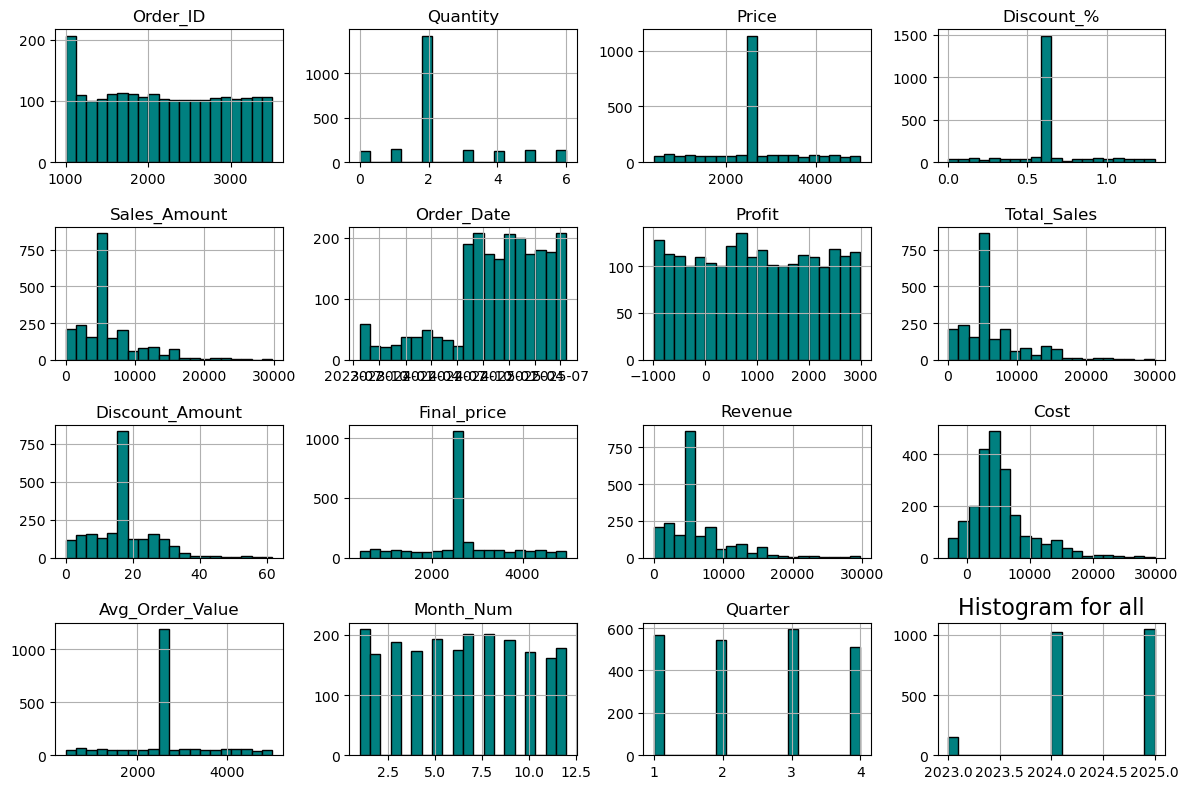

In [139]:
df.hist(bins=20,color="teal",edgecolor="black",figsize=(12,8))
plt.title("Histogram for all",fontsize=16)
plt.tight_layout()
plt.show()

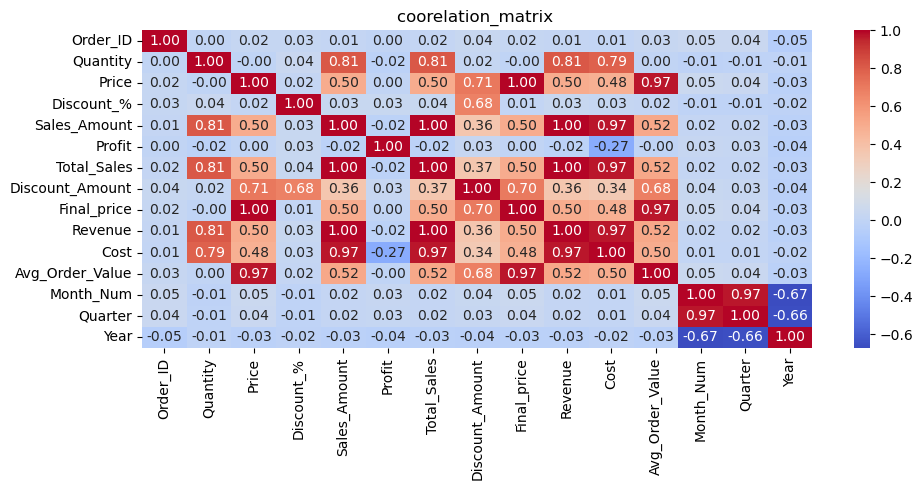

In [140]:
plt.figure(figsize=(10,5))
coorelation_matrix=df.corr(numeric_only=True)
sns.heatmap(coorelation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("coorelation_matrix ")
plt.tight_layout()
plt.show()

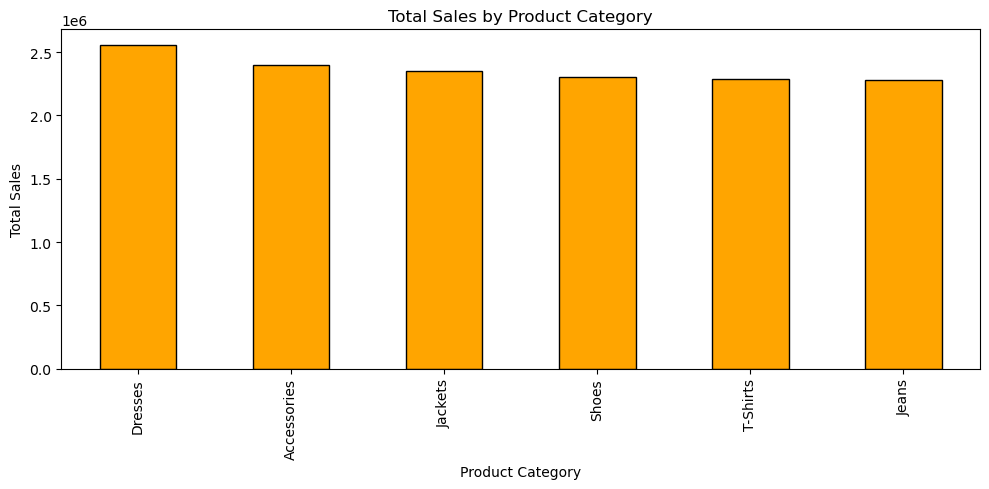

In [141]:
plt.figure(figsize=(10,5))
df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False).plot(kind="bar", color="Orange", edgecolor="black")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

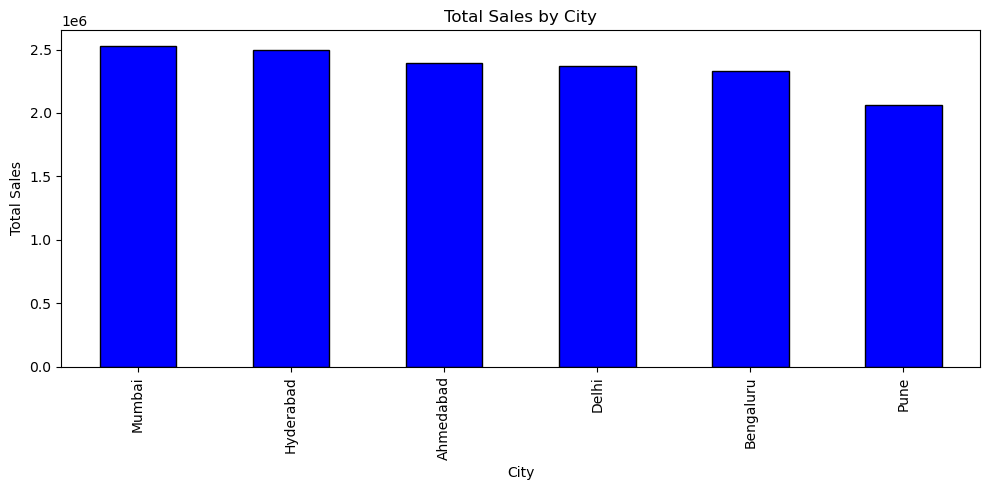

In [142]:
plt.figure(figsize=(10,5))
df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).plot(kind="bar", color="Blue", edgecolor="black")
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

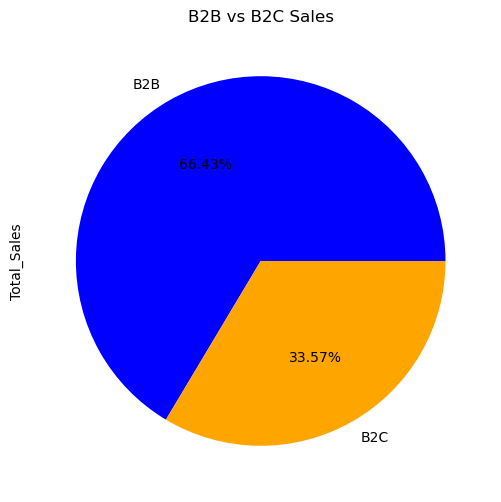

In [143]:
plt.figure(figsize=(10,6))
df.groupby("Segment")["Total_Sales"].sum().plot(kind="pie", autopct="%1.2f%%", colors=["Blue","Orange"])
plt.title("B2B vs B2C Sales")
plt.show()

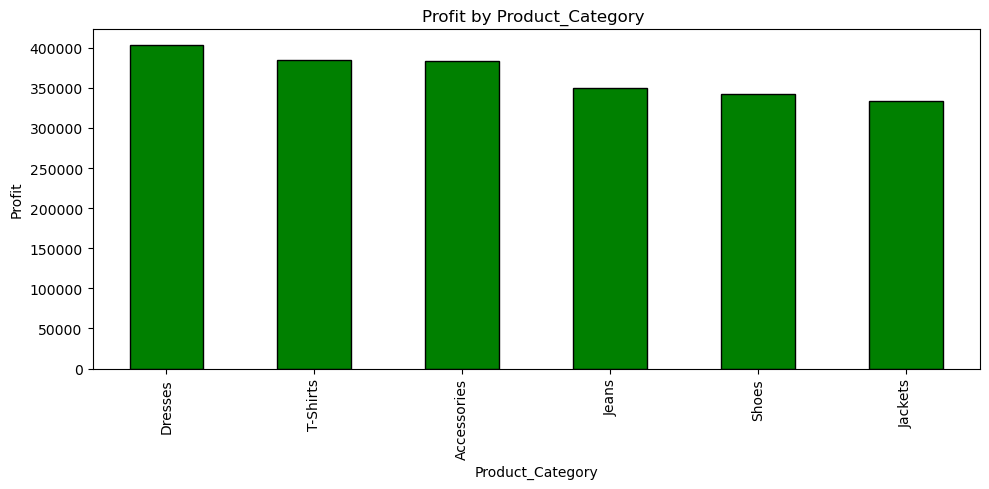

In [144]:
plt.figure(figsize=(10,5))
df.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False).plot(kind='bar',color='green',edgecolor='black')
plt.title("Profit by Product_Category ")
plt.xlabel("Product_Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

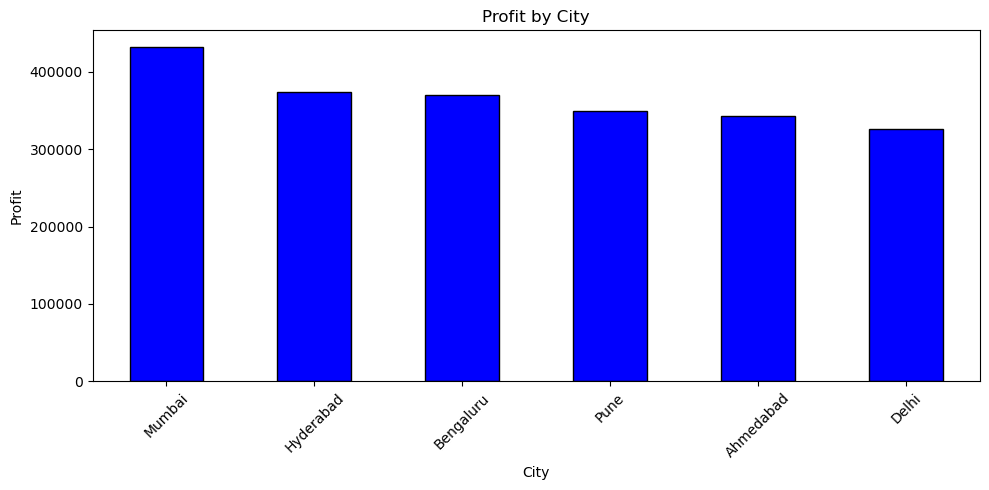

In [145]:
plt.figure(figsize=(10, 5))
df.groupby("City")["Profit"].sum().sort_values(ascending=False).plot(kind="bar", color="blue", edgecolor="black")
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

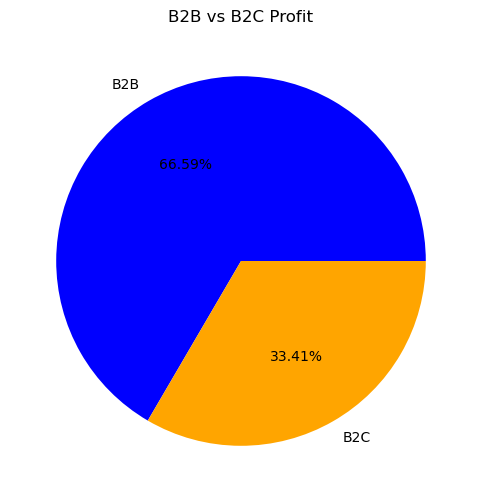

In [146]:
plt.figure(figsize=(6, 6))
df.groupby("Segment")["Profit"].sum().plot(kind="pie", autopct="%1.2f%%", colors=["blue", "Orange"])
plt.title("B2B vs B2C Profit")
plt.ylabel("")
plt.show()

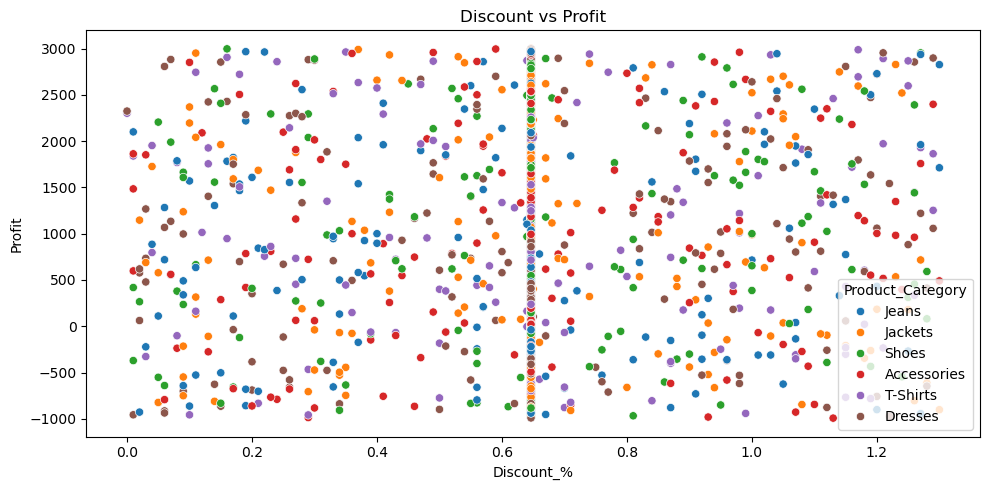

In [147]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x="Discount_%",y="Profit",hue="Product_Category")
plt.title("Discount vs Profit")
plt.tight_layout()
plt.show()

In [148]:
loss_orders = df[df["Profit"] < 0]
print("Total Loss Orders:", len(loss_orders))
print(loss_orders[["Order_ID","Product_Category","City","Segment","Profit"]].head(10))

Total Loss Orders: 559
    Order_ID Product_Category       City Segment  Profit
2       1002          Jackets     Mumbai     B2B -158.03
8       1008      Accessories  Ahmedabad     B2C -886.80
9       1009         T-Shirts  Bengaluru     B2B -972.73
10      1010         T-Shirts       Pune     B2B -950.38
14      1014            Shoes  Hyderabad     B2B -889.25
17      1017         T-Shirts     Mumbai     B2B -195.65
21      1021          Dresses  Bengaluru     B2B -705.72
22      1031          Dresses       Pune     B2C -863.90
23      1023            Shoes     Mumbai     B2B -875.51
26      1026      Accessories  Ahmedabad     B2B -194.77


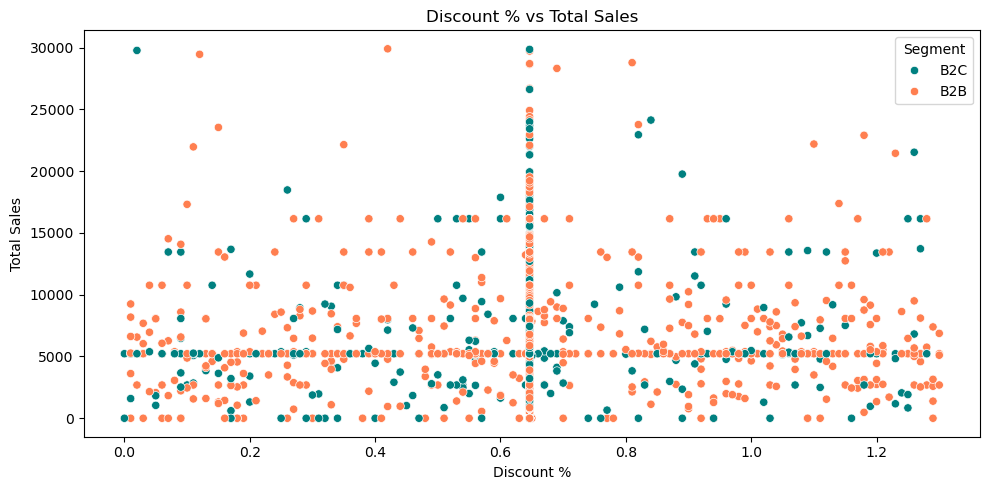

In [149]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="Discount_%", y="Total_Sales", hue="Segment", palette=["teal", "coral"])
plt.title("Discount % vs Total Sales")
plt.xlabel("Discount %")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

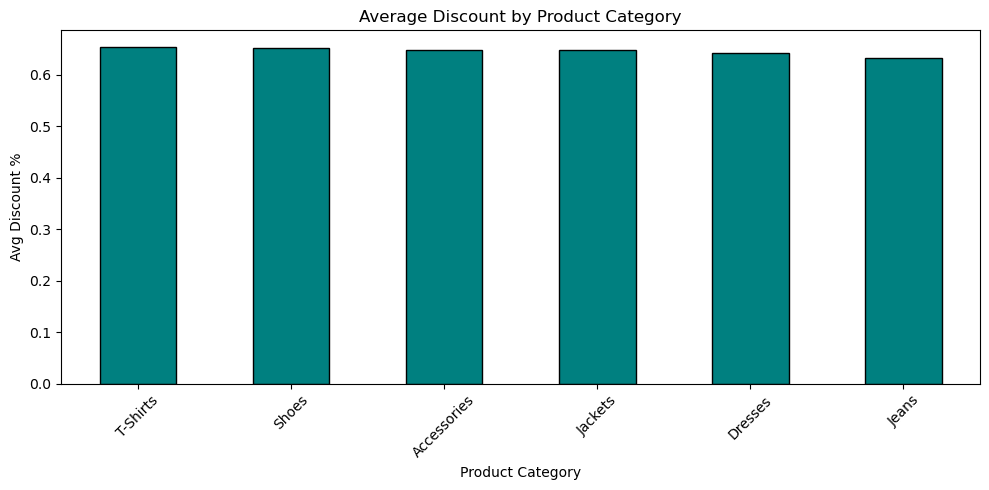

In [150]:
plt.figure(figsize=(10, 5))
df.groupby("Product_Category")["Discount_%"].mean().sort_values(ascending=False).plot(kind="bar", color="teal", edgecolor="black")
plt.title("Average Discount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Avg Discount %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

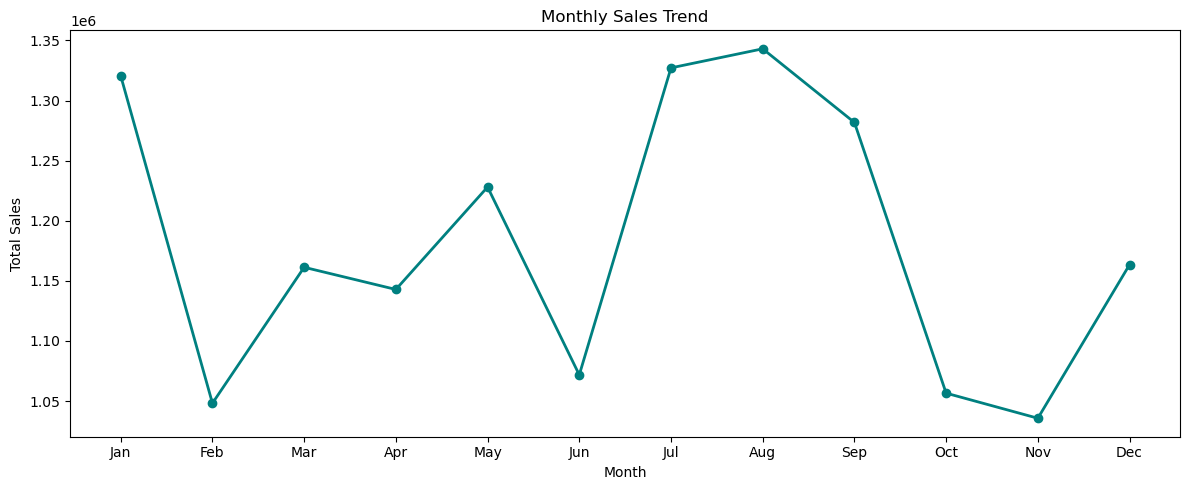

In [151]:
plt.figure(figsize=(12, 5))
df.groupby("Month_Num")["Total_Sales"].sum().plot(kind="line", marker="o", color="teal", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

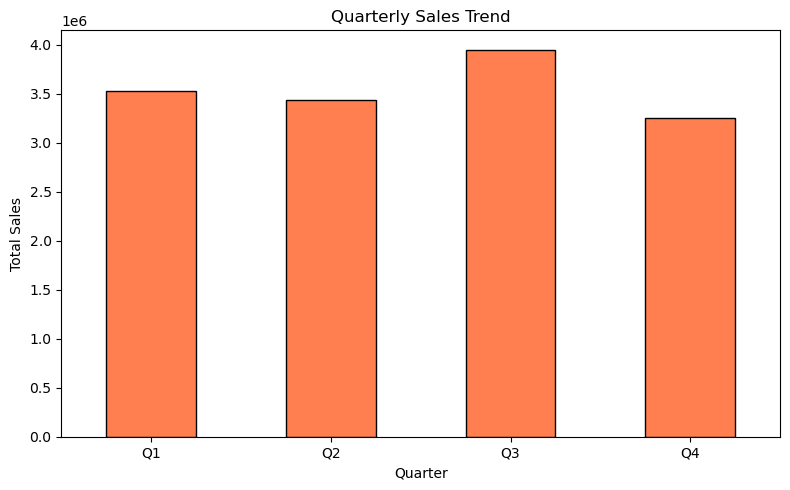

In [152]:
plt.figure(figsize=(8, 5))
df.groupby("Quarter")["Total_Sales"].sum().plot(kind="bar", color="coral", edgecolor="black")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks([0,1,2,3], ["Q1","Q2","Q3","Q4"], rotation=0)
plt.tight_layout()
plt.show()

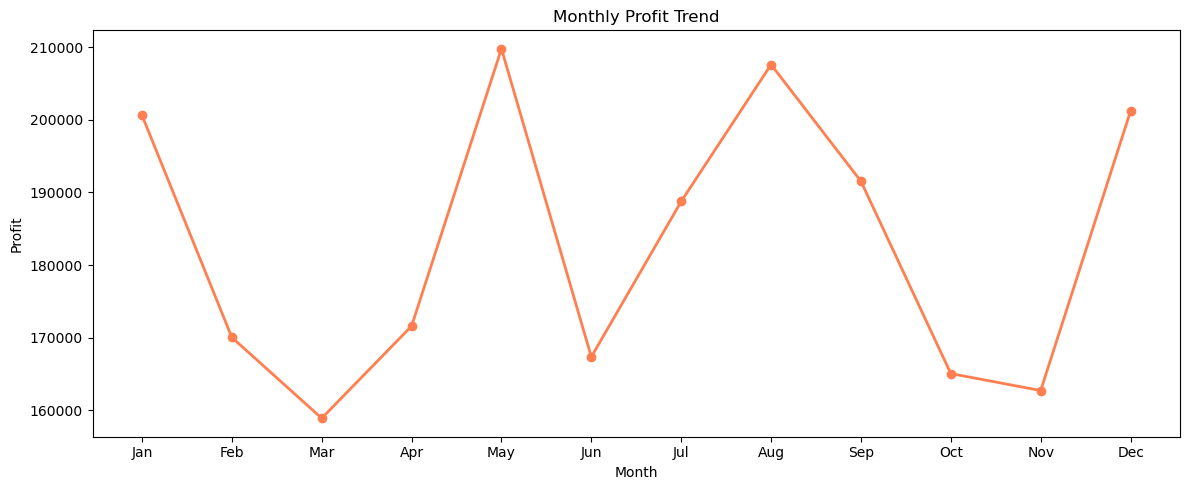

In [153]:
plt.figure(figsize=(12, 5))
df.groupby("Month_Num")["Profit"].sum().plot(kind="line", marker="o", color="coral", linewidth=2)
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

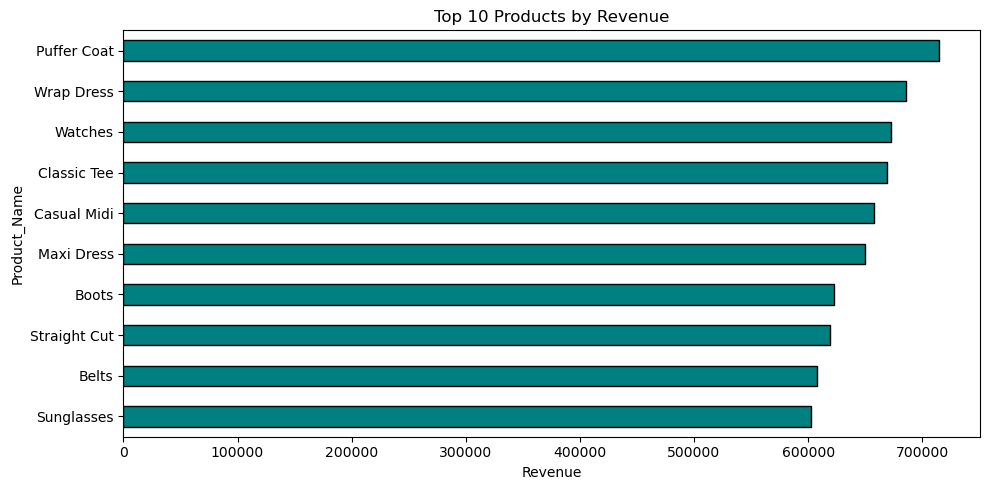

In [154]:
plt.figure(figsize=(10, 5))
df.groupby("Product_Name")["Revenue"].sum().nlargest(10).sort_values().plot(kind="barh", color="teal", edgecolor="black")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

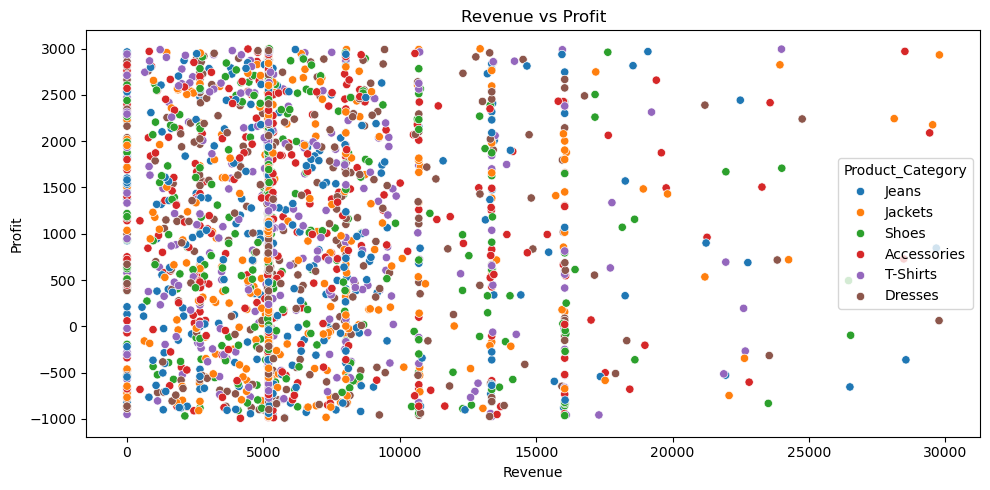

In [155]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x="Revenue",y="Profit", hue="Product_Category")
plt.title("Revenue vs Profit")
plt.tight_layout()
plt.show()

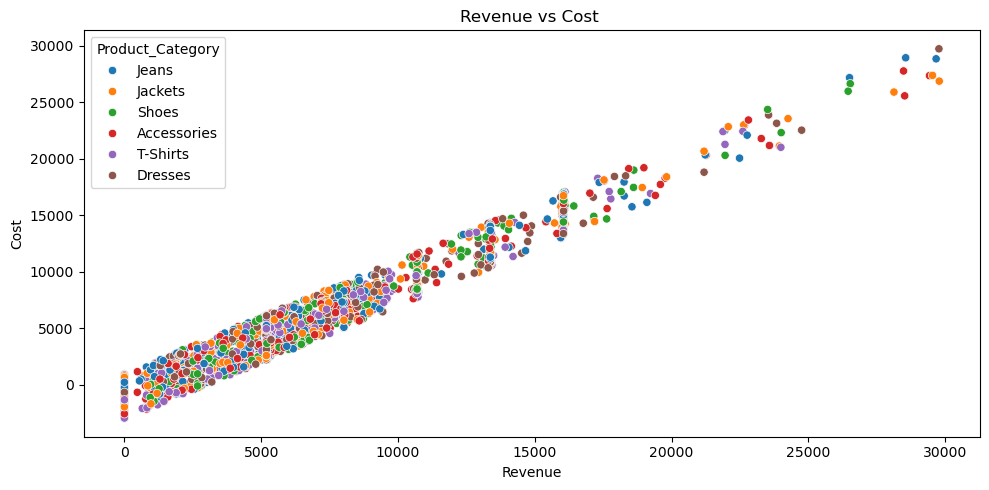

In [156]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,x="Revenue",y="Cost",hue="Product_Category")
plt.title("Revenue vs Cost ")
plt.tight_layout()
plt.show()

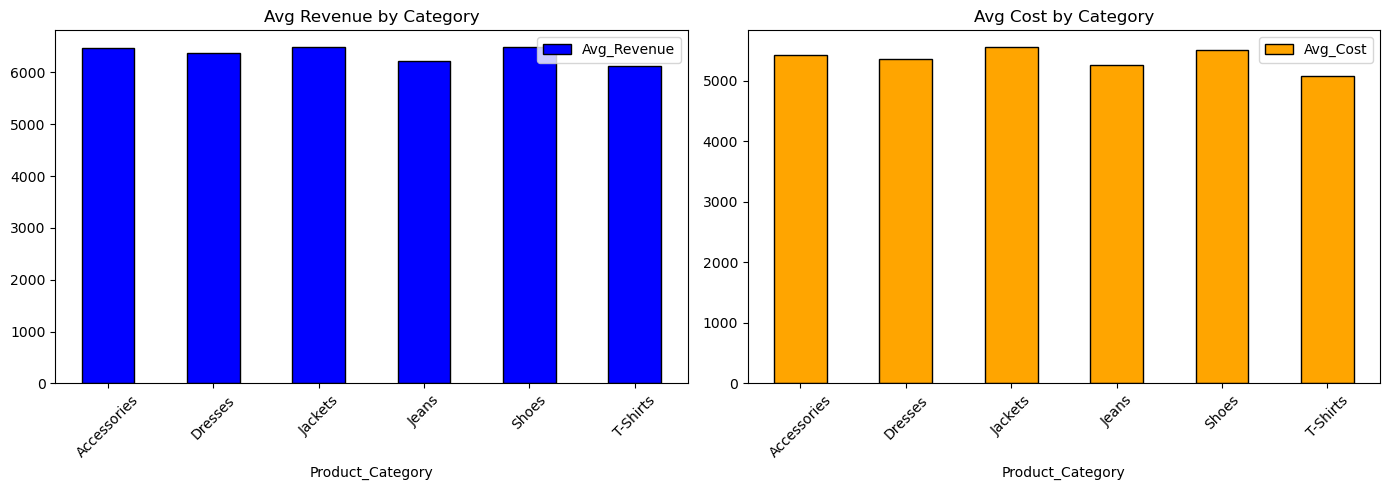

In [157]:
category_analysis = df.groupby("Product_Category").agg(
    Avg_Revenue = ("Revenue", "mean"),
    Avg_Cost    = ("Cost",    "mean")
).round(2).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
category_analysis.plot(kind="bar", x="Product_Category", y="Avg_Revenue", ax=axes[0], color="Blue", edgecolor="black")
axes[0].set_title("Avg Revenue by Category")
axes[0].tick_params(axis="x", rotation=45)

category_analysis.plot(kind="bar", x="Product_Category", y="Avg_Cost", ax=axes[1], color="Orange", edgecolor="black")
axes[1].set_title("Avg Cost by Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [158]:
df["Discount_%"].max()

1.3

In [159]:
print("Total Revenue  :", df["Revenue"].sum().round(2))
print("Total Profit   :", df["Profit"].sum().round(2))
print("Total Orders   :", df["Order_ID"].nunique())
print("Total Customers:", df["Customer_Name"].nunique())
print("Total Cities   :", df["City"].nunique())
print("Loss Orders    :", len(df[df["Profit"] < 0]))

Total Revenue  : 14087666.03
Total Profit   : 2195362.55
Total Orders   : 2124
Total Customers: 2182
Total Cities   : 6
Loss Orders    : 559


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2217 entries, 0 to 2499
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2217 non-null   int64         
 1   Customer_Name     2217 non-null   object        
 2   Product_Category  2217 non-null   object        
 3   Product_Name      2217 non-null   object        
 4   Quantity          2217 non-null   float64       
 5   Price             2217 non-null   float64       
 6   Discount_%        2217 non-null   float64       
 7   Sales_Amount      2217 non-null   float64       
 8   Order_Date        2217 non-null   datetime64[ns]
 9   City              2217 non-null   object        
 10  Segment           2217 non-null   object        
 11  Profit            2217 non-null   float64       
 12  Total_Sales       2217 non-null   float64       
 13  Discount_Amount   2217 non-null   float64       
 14  Final_price       2217 non-nu

In [162]:
df.to_excel("Snitch_Fashion_Sales__.xlsx",index=False)